# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/processed_full_data'+runs+'runs'+'-'+comment+'.pkl'
# d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
# '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl'
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/list_processed_full_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_I,I_0,S_0,N_0,d_S,K_H,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,harm_pI,harm_pS,max_eM_fold,frac_cM,log_T_pEcyteM,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,scaled_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
0,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.0,0.0,4.0,-3.0,1.5,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,1.170399e+07,687.438163,0.759668,0.509950,0.008473,0.0,8.72,0.42,8.30,6.526095,1.793281,0.002566,0.015048,3.349148,1.170713,0.000315,0.000069
1,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.0,0.0,4.0,-3.0,1.5,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,1.170399e+07,743.565995,0.784617,0.490099,0.008741,0.0,8.72,0.40,8.32,6.526069,1.793260,0.003123,0.015048,3.349148,1.170713,0.000314,0.000074
2,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.0,0.0,4.0,-3.0,1.5,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,1.170512e+07,387.255517,0.563481,0.463840,0.004618,0.0,8.71,0.25,8.46,6.526194,1.793362,0.002415,0.015046,3.349148,1.170713,0.000201,0.000039
3,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.0,0.0,4.0,-3.0,1.5,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,1.170581e+07,249.459415,0.440909,0.486486,0.003321,0.0,8.70,0.30,8.40,6.526232,1.793394,0.001252,0.015046,3.349148,1.170713,0.000133,0.000025
4,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.0,0.0,4.0,-3.0,1.5,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,1.170560e+07,279.428684,0.454845,0.431421,0.003169,0.0,8.70,0.31,8.39,6.526225,1.793387,0.001249,0.015046,3.349148,1.170713,0.000153,0.000028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70296169,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,-1.5,-1.5,0.0,0.0,0.0,0.0,4.0,1.118375e+07,7315.502373,0.460597,0.159384,0.005382,0.0,30.00,0.20,29.80,0.056775,0.921290,0.008087,0.519145,3.172940,1.119738,0.001364,0.000732
70296170,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,-1.5,-1.5,2.0,0.0,0.0,0.0,-4.0,1.110300e+07,55497.428870,1.496085,0.178953,0.049398,0.0,30.00,0.20,29.80,0.056382,0.916699,0.033797,0.518979,3.172940,1.119738,0.009439,0.005550
70296171,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,-1.5,-1.5,2.0,0.0,0.0,0.0,-2.0,1.115373e+07,23891.181854,1.153662,0.164183,0.016963,0.0,30.00,0.15,29.85,0.056631,0.919752,0.020742,0.519217,3.172940,1.119738,0.004365,0.002389
70296172,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,-1.5,-1.5,2.0,0.0,0.0,0.0,0.0,1.118240e+07,8035.111063,0.730136,0.184478,0.006144,0.0,30.00,0.26,29.74,0.056769,0.921224,0.009317,0.519150,3.172940,1.119738,0.001498,0.000804


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)
tol = 1e-2

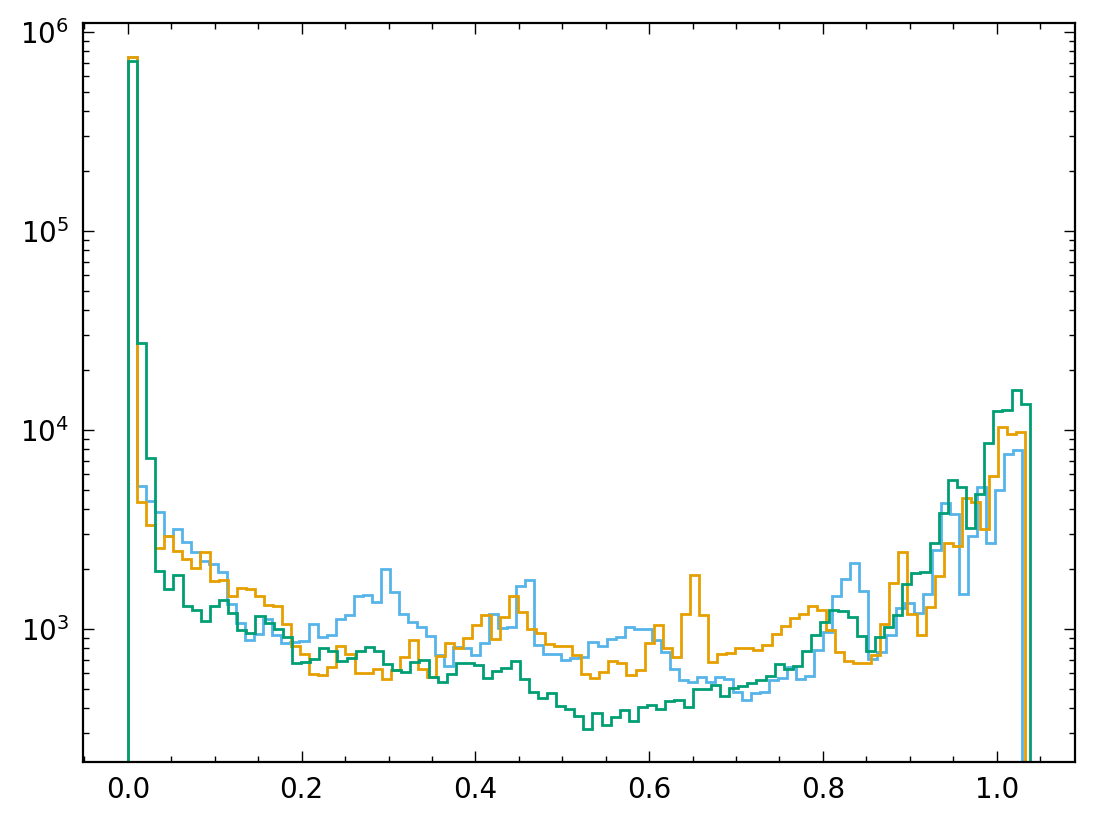

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,0.532046,0.000100,0.003282,3.271973
1,0.544286,0.001341,0.087222,3.304282
2,0.556817,0.009183,0.467280,3.255210
3,0.562162,0.000164,0.003282,3.279113
4,0.569737,0.020705,0.815841,3.263560
...,...,...,...,...
223,3.120998,6.308881,2.026495,3.270358
224,3.172940,0.056840,0.921962,3.670806
225,3.349148,6.526300,1.793448,3.409487
226,5.611731,0.460502,0.921962,3.710302


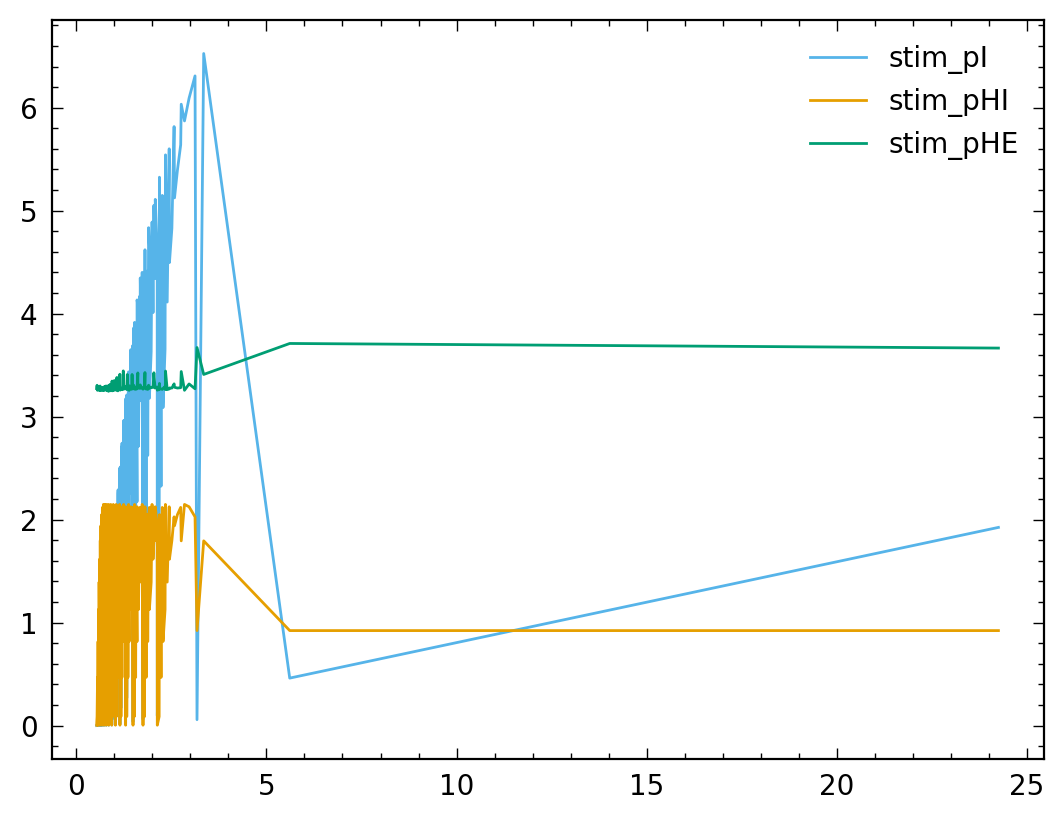

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

In [6]:
# # Explore noise in the data
# fig, axs = plt.subplots(1, len(perf_vars), 
#                               figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)


# data_mean = clustered_mean_df.groupby(reg + vir_vars, as_index = False).std()
        
# for i, var in enumerate(perf_vars):
#     im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
#                         (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
#                       marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
#                         edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

#     if module_index + j == 0: 
#         axs[i].minorticks_off()
#         axs[i].yaxis.set_tick_params(labelbottom=True)
#         axs[i].xaxis.set_tick_params(labelbottom=True)
#         axs[i].tick_params(axis='both', which='major', labelsize=8)
#         axs[i].set_box_aspect(1)
#         axs[i].locator_params(axis='y', nbins=4)
#         axs[i].locator_params(axis='x', nbins=4)
#         axs[i].set_ylabel("St. dev.\n"+perf_labels[i], fontsize = 12)
#         axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

# axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
# fig.subplots_adjust(wspace=.4, hspace=.35)
# #plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 17
fevals: 144
fevals: 10
fevals: 13
fevals: 69
fevals: 120
fevals: 55
fevals: 21
fevals: 11
fevals: 13
fevals: 7
fevals: 12
fevals: 35
fevals: 54
fevals: 11
fevals: 13


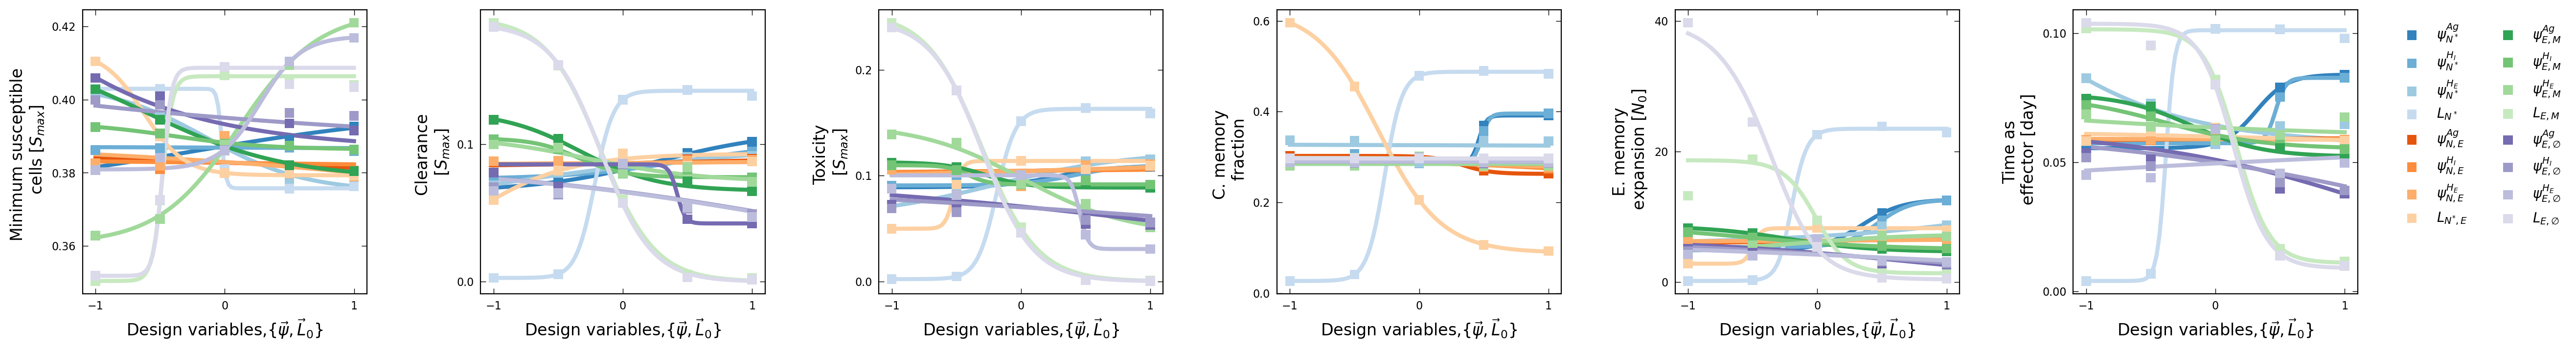

In [7]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, var in enumerate(perf_vars):
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
                                (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - tol*y_std, np.minimum(2*y_min, 0), -4*L0_max, -4*L0_max], 
                                             [2*y_max if y_max > 0 else y_std*tol, np.maximum(y_min, 0) + y_std*tol, 4*L0_max, 4*L0_max]),
                                   maxfev=10000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), (10**sigmoid_1d(x, *popt) - 1) if i == 4 or i == 5 else sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 16)
                axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 16)

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.4, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=300, bbox_inches="tight")

In [8]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [9]:
# Regress Performance measures on regulation parameters
num_cpu = 145
variables = reg
tol = 1e-2

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_std*tol, np.minimum(0.0, y_min)] + len(variables)*[-15*L0_max] + num_modules*[-15*L0_max], 
                                     [1.0 if perf == "frac_cM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[15*L0_max] + num_modules*[15*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, 
                                                                                               np.amax(input['scaled_min_pS'].values),
                                                                                               input['harm_pI_noprotection'].values[0],
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [10]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [11]:
# View result
perf_choice = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None,'display.max_rows', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1,1.172632e+00,3.287117e-03,4.125338,0.036739,0.101485,4.117401,0.433729,0.011686,0.012698,1.418415,-7.396664,-0.346059,-0.464655,-4.010744,-4.945647,-0.169201,-0.259885,-2.622884,3.910640,6.511428,-1.945571,-1.910782,1.050478e-03,2.120107e-04,3.940016e-02,5.319994e-03,5.361906e-03,3.971536e-02,6.014929e-03,5.440877e-03,5.440983e-03,2.288586e-02,5.026717e-02,7.196748e-03,7.670877e-03,2.911462e-02,2.589223e-02,6.835538e-03,6.985601e-03,1.372786e-02,4.059230e-02,9.246228e-02,8.610942e-03,7.692245e-03,0.150000,1.000000e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,1.173785e-01,1.169345e+00,0.000000e+00,0.000066,1.0,1.033910e-01,3.287117e-01,0.970261,1.170713,6.526300,1.793448,3.111044,3.349148
7,1.172391e+00,3.190123e-03,3.680945,0.050303,0.143684,3.944797,0.372967,0.023769,0.034012,1.555383,-4.704024,-0.296340,-0.407480,-2.881278,-4.456649,-0.225314,-0.294549,-2.616761,3.539642,7.074517,-1.659549,-1.886791,1.165361e-03,2.176878e-04,3.166586e-02,5.609593e-03,5.712314e-03,3.283102e-02,6.014467e-03,5.589713e-03,5.592076e-03,3.285915e-02,3.007315e-02,5.167079e-03,5.387359e-03,2.030505e-02,2.408600e-02,6.611491e-03,6.714993e-03,1.512046e-02,3.163017e-02,1.324595e-01,6.994756e-03,7.875854e-03,0.150000,1.637894e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,1.161056e-01,1.169131e+00,0.000000e+00,0.000060,1.0,1.059620e-01,3.259905e-01,0.945033,1.170713,6.033823,1.793448,3.112549,2.758122
13,1.172078e+00,3.235447e-03,3.460463,0.096161,0.343978,4.356474,0.234172,0.011190,0.019393,1.339508,-3.930345,-0.198506,-0.372663,-3.839315,-3.223405,-0.253832,-0.615796,-2.592244,3.327243,6.166749,-1.837635,-1.839599,1.122680e-03,2.102591e-04,3.244679e-02,6.560830e-03,7.246048e-03,3.837584e-02,5.337208e-03,5.168120e-03,5.168971e-03,2.332202e-02,2.567992e-02,5.279369e-03,5.700121e-03,2.284920e-02,1.790959e-02,6.031992e-03,6.301830e-03,1.383289e-02,3.052060e-02,9.420442e-02,7.887349e-03,7.261428e-03,0.150000,2.682696e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,1.146817e-01,1.168842e+00,0.000000e+00,0.000054,1.0,1.031106e-01,3.235447e-01,0.910206,1.170713,5.541939,1.793448,3.115016,2.344404
19,1.171728e+00,3.200546e-03,3.211379,0.108078,1.041102,5.669992,0.188932,0.007692,0.003471,1.371151,-3.473143,-0.213173,-0.394657,-3.720549,-2.706315,-0.194935,-0.334282,-2.727768,3.209636,6.228490,-1.895574,-1.968737,1.057324e-03,1.993675e-04,3.174739e-02,6.918687e-03,1.163505e-02,5.169857e-02,4.921950e-03,4.812946e-03,4.812792e-03,2.287070e-02,1.859319e-02,4.903441e-03,5.397184e-03,1.950877e-02,1.422358e-02,5.505122e-03,5.759827e-03,1.353649e-02,2.812631e-02,9.231671e-02,7.864395e-03,7.653662e-03,0.150000,4.393971e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,1.125192e-01,1.168528e+00,0.000000e+00,0.000047,1.0,9.834294e-02,3.200546e-01,0.887973,1.170713,5.051025,1.793448,3.149474,2.038612
25,1.171044e+00,3.164335e-03,3.477654,0.201940,1.833873,9.978556,0.165490,0.010894,0.017935,1.542513,-2.460437,-0.287736,-0.593091,-3.137928,-2.311054,-0.233818,-0.446319,-2.618183,3.913776,6.905848,-1.815814,-2.035890,1.037116e-03,1.898770e-04,4.162505e-02,9.265970e-03,2.454339e-02,1.195799e-01,4.680852e-03,4.600261e-03,4.600895e-03,3.041595e-02,1.279762e-02,4.367157e-03,5.073843e-03,1.579867e-02,1.125843e-02,5.179966e-03,5.531827e-03,1

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

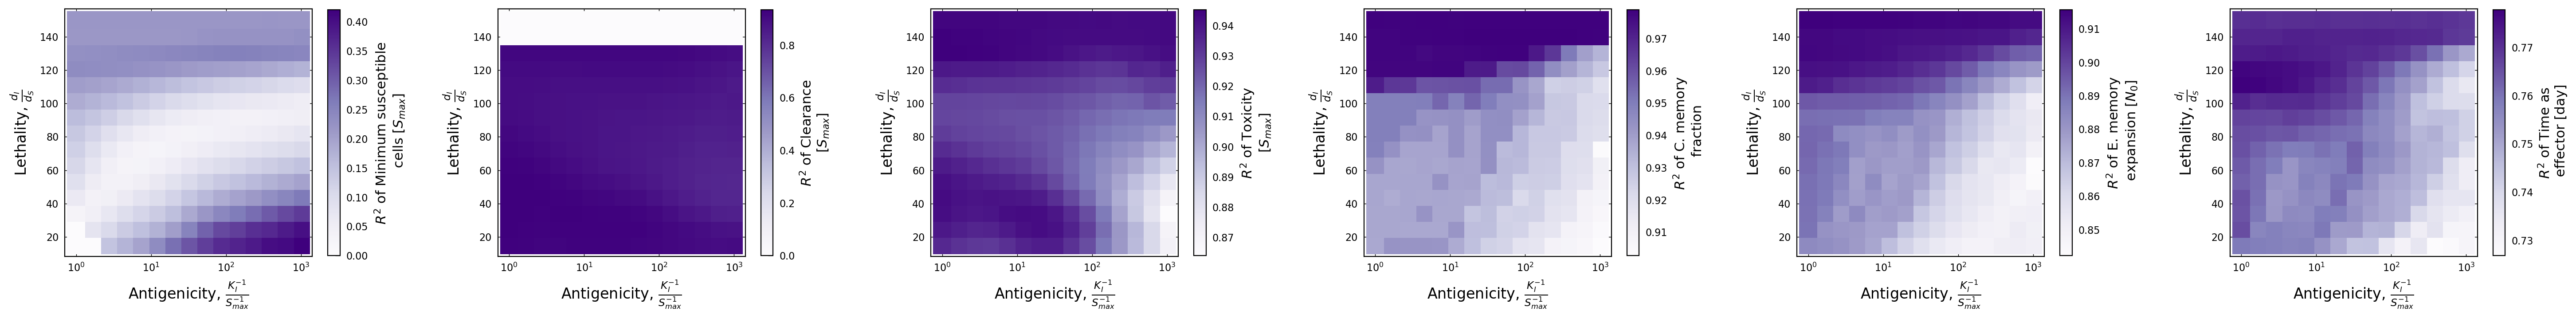

In [12]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2)*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

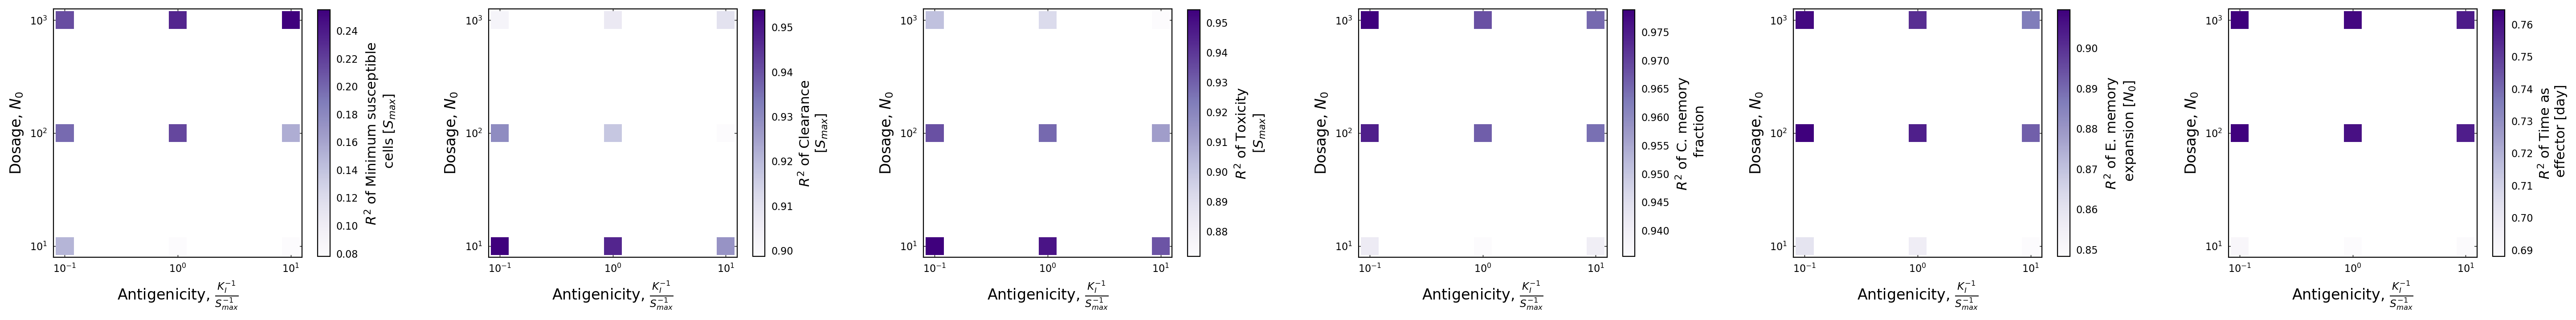

In [13]:
# Examine goodness of fit through R-squared
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = vir_vars[1], vir_vars[4]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 > I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2) #*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname], data[y_varname],
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    axs[i].semilogx()
    axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel("Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", fontsize = 12)
    ax.set_ylabel("Dosage, "+r"$N_0$", fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared-cancers'+'.png', dpi=150, bbox_inches="tight")

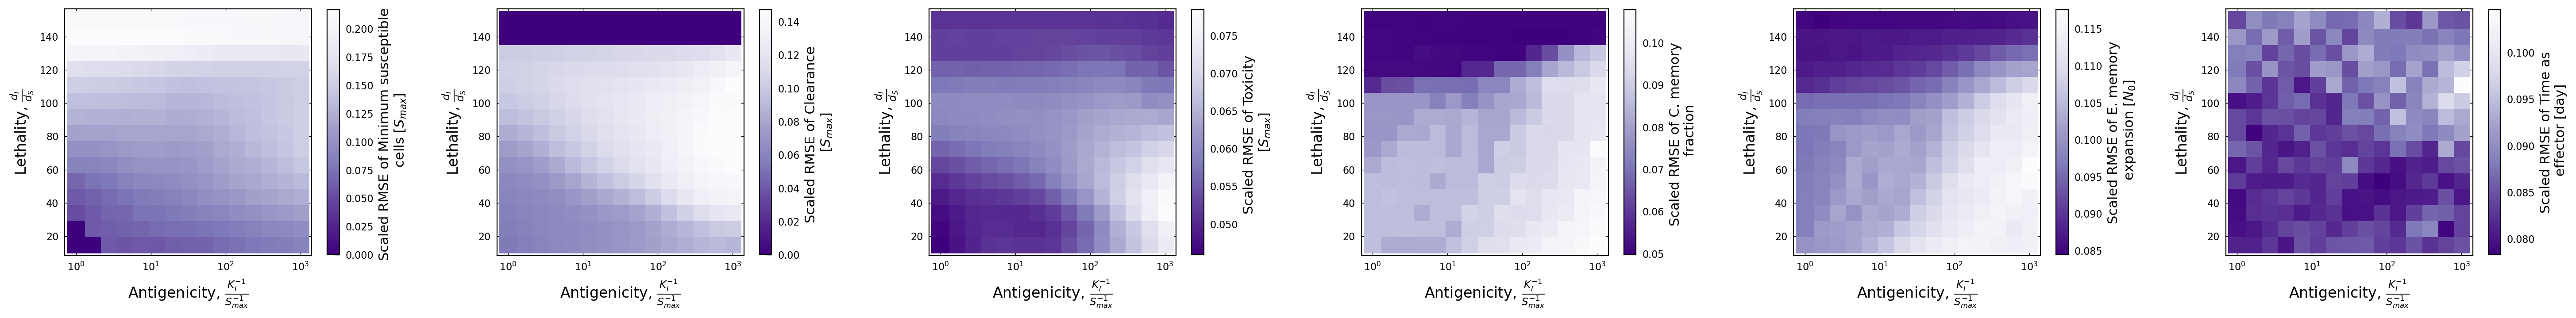

In [14]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_rmse_over_max = (data.rmse/data.y_max)*(data.y_std > tol)
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

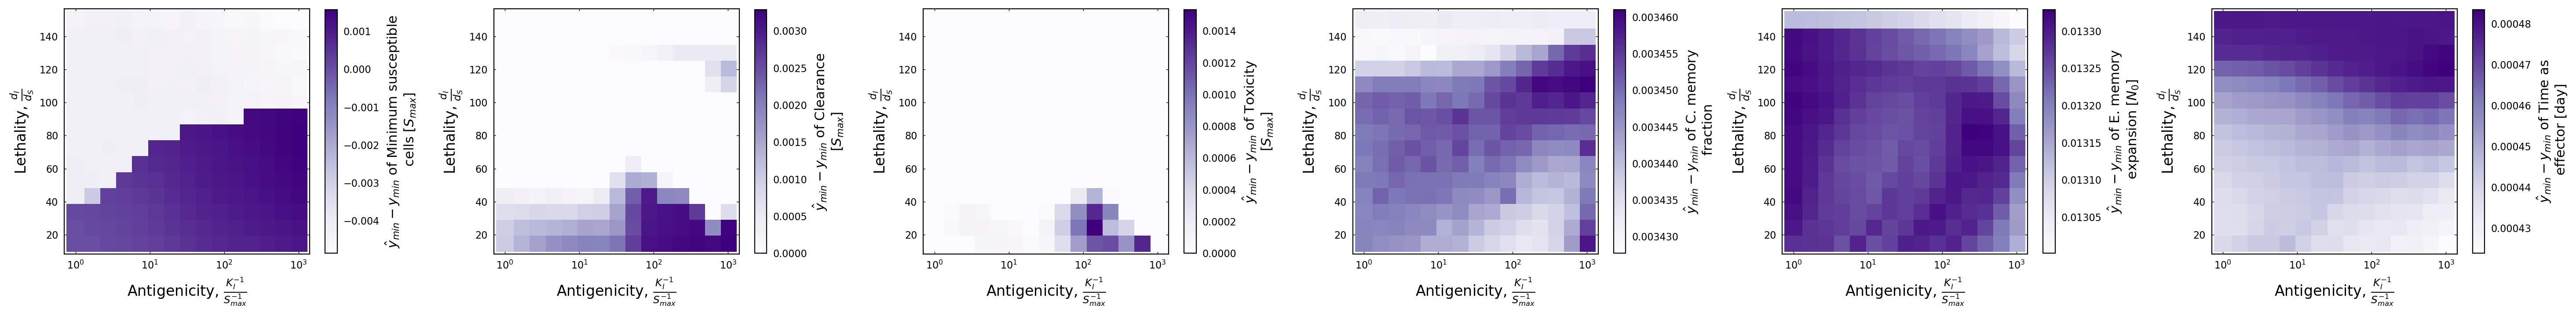

In [15]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{min} - y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_min - data.min_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

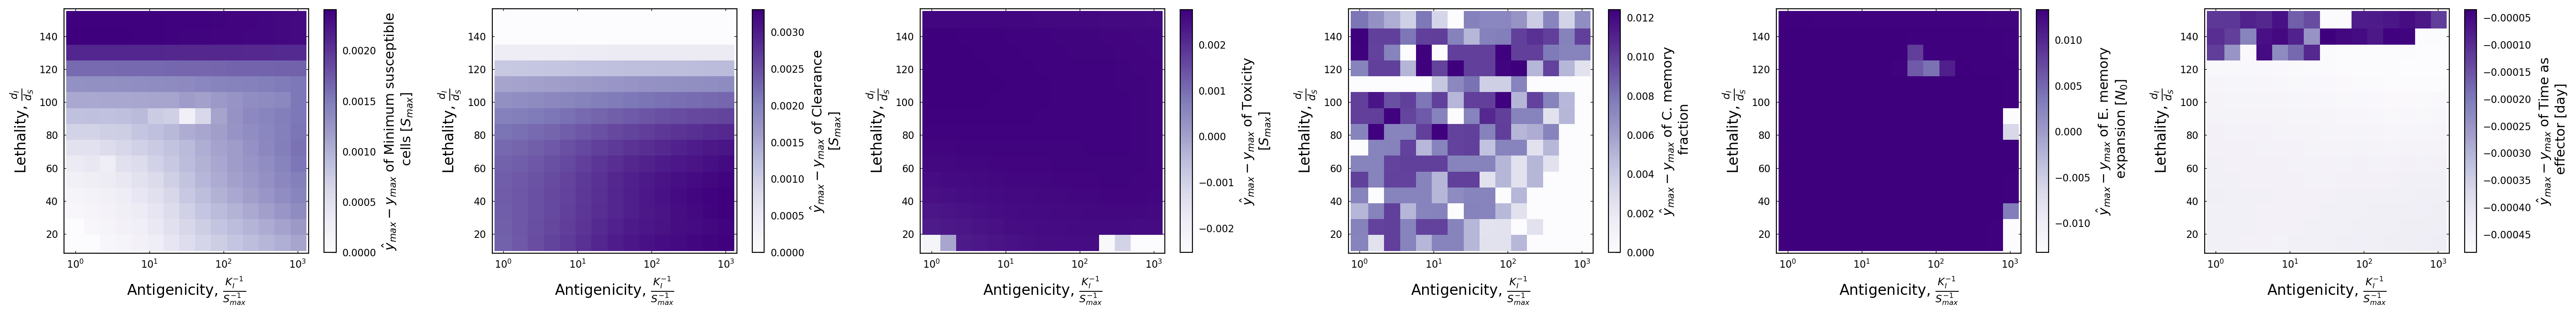

In [16]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_max - data.max_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

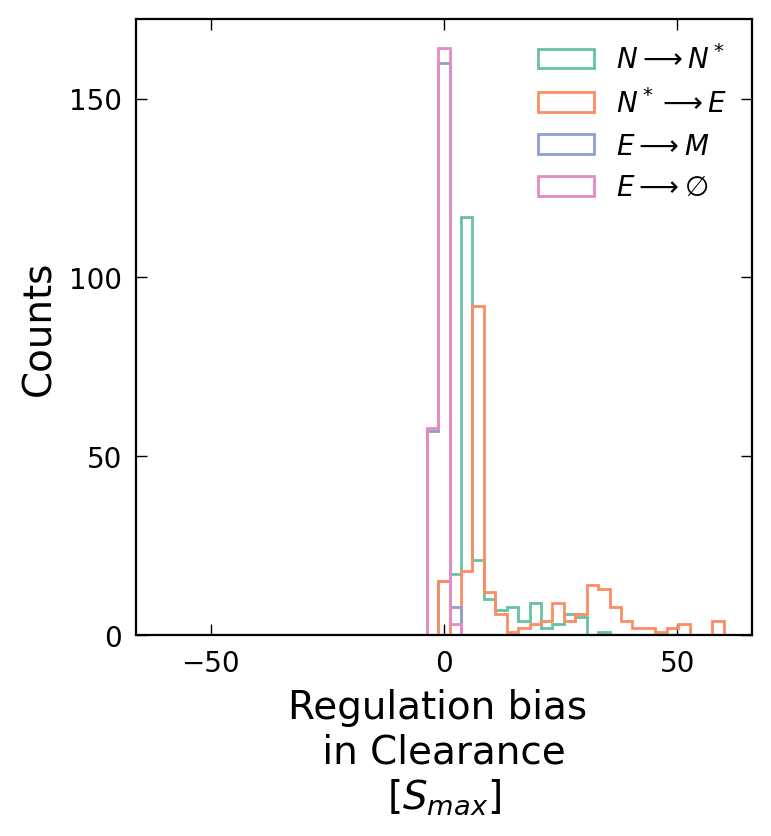

In [17]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

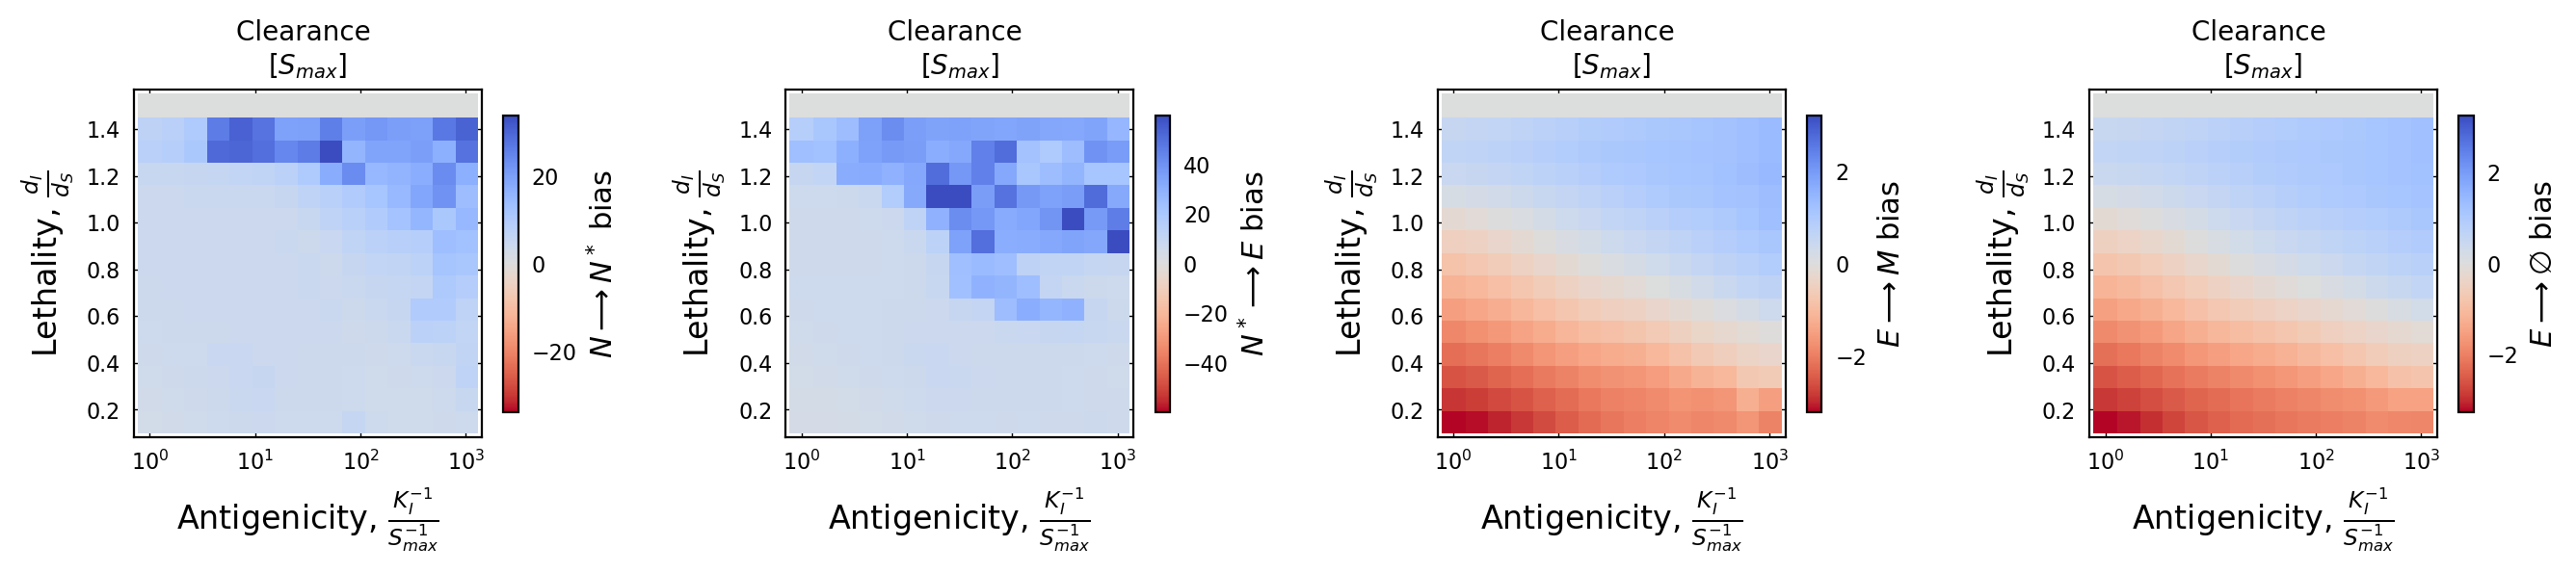

In [18]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1250/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    z = data[z_varname]
    range = np.amax(np.abs(z))
    
    im = axs[i].scatter(S_0/data[x_varname] if x_varname == 'K_I' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_I' else data[y_varname],
                      marker ='s', s = size, c = z, cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

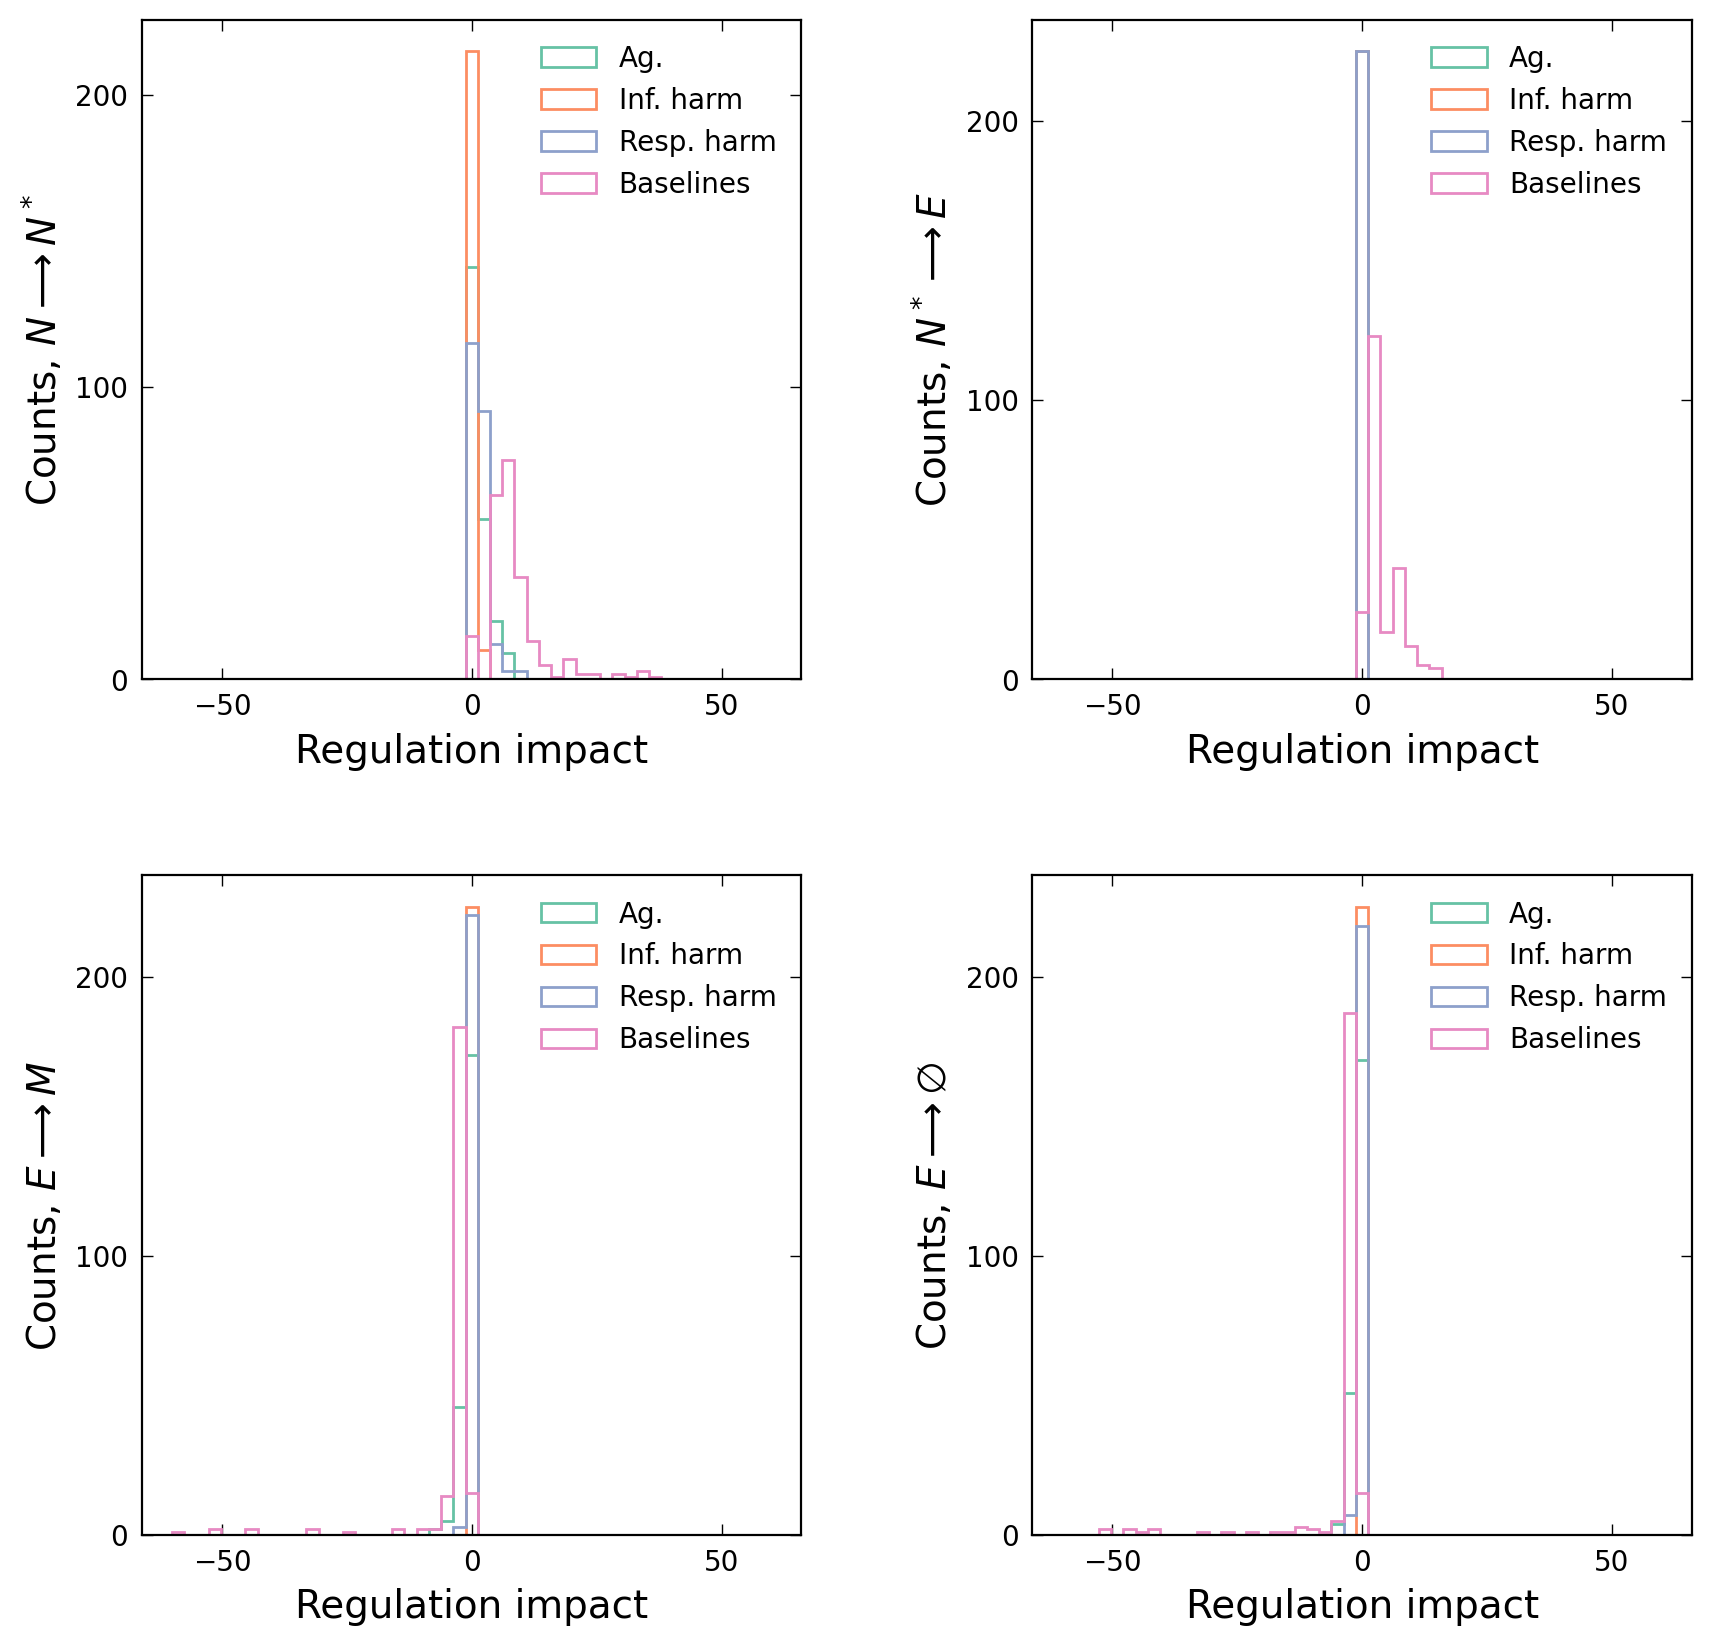

In [19]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [20]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm


In [21]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1351,1.020538,9.096347e-36,3.642939,1.761131,0.929187,4.961450,0.577113,0.279205,0.039490,1.228813,-1.137385,-0.605706,-0.583873,-1.927116,-1.139464,-0.599232,-0.568331,-1.873818,3.570678,4.535115,-1.388142,-1.355312,0.000938,0.000136,0.030060,0.015300,0.009393,0.040303,0.004370,0.003791,0.003580,0.005618,0.004578,0.003417,0.003379,0.006101,0.005396,0.004474,0.004440,0.006035,0.029798,0.021787,0.004390,0.004332,0.01,1000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.085204,1.018070,0.000000e+00,0.000009,1.0,0.066253,0.246792,0.808994,1.119738,1.924058,0.921962,2.052930,24.253500
1357,1.033193,2.784054e-33,3.724992,1.819434,0.974924,5.018838,0.411249,0.221704,0.018442,1.169153,-1.640281,-0.854364,-0.463639,-2.494357,-1.713069,-0.884110,-0.459985,-2.516095,3.634184,5.927887,0.246268,0.293850,0.000939,0.000224,0.037145,0.019016,0.011671,0.049352,0.006339,0.006048,0.005880,0.020450,0.013053,0.007714,0.005571,0.018753,0.017388,0.010253,0.007333,0.024000,0.036752,0.083262,0.004158,0.004135,0.01,1000000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.143043,1.029875,0.000000e+00,0.000143,1.0,0.105627,0.331832,0.806942,1.119738,1.924058,0.921962,3.165742,24.253500
1363,1.041808,4.348170e-05,3.485357,1.600700,0.984256,4.819657,0.436141,0.220645,-0.008035,10.382369,-1.505830,-0.791260,-0.530845,-2.350709,-1.726346,-0.878583,-0.535515,-2.525958,3.670005,44.422882,0.784174,0.813873,0.000810,0.000237,0.032132,0.015748,0.010842,0.043695,0.052165,0.033758,0.012294,228685.592449,0.009329,0.005925,0.004954,0.013213,0.013494,0.008230,0.006588,0.018149,0.034180,914742.894331,0.004657,0.004651,0.01,1000000.0,0.1,100000.0,1000.0,10000000.0,500000.0,0.170039,1.038175,0.000000e+00,0.001410,1.0,0.109184,0.363248,0.812907,1.119738,1.924058,0.921962,3.630228,24.253500
1369,0.987060,-1.862645e-16,0.724039,2.685173,1.144833,6.104940,0.055034,0.264874,0.042960,1.136715,-0.110826,-0.455958,-0.801255,-1.404993,-0.115443,-0.461783,-0.779111,-1.415255,3.688093,3.666236,-2.263416,-2.257871,0.000888,0.000078,0.007702,0.020786,0.010120,0.045827,0.002639,0.002728,0.002638,0.003328,0.001761,0.002029,0.002519,0.003181,0.002580,0.002799,0.003157,0.003288,0.028980,0.011957,0.005188,0.005477,0.01,10000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.049891,0.985405,-1.862645e-16,0.000003,1.0,0.037939,0.165425,0.577602,1.119738,0.460502,0.921962,2.011160,5.611731
1375,1.024571,-1.862645e-16,0.789513,2.708732,1.566836,6.114583,0.057380,0.214890,0.050615,1.076348,-0.169351,-0.707940,-0.526483,-1.902180,-0.190839,-0.680753,-0.505979,-1.822753,3.540100,4.911360,-0.406066,-0.344088,0.000993,0.000175,0.009866,0.025503,0.016088,0.055431,0.004103,0.004229,0.004101,0.010704,0.003265,0.004826,0.004229,0.009837,0.004371,0.005794,0.005210,0.010506,0.032618,0.043317,0.003471,0.003464,0.01,10000000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.114676,1.021705,-1.862645e-16,0.000044,1.0,0.082537,0.286595,0.574069,1.119738,0.460502,0.921962,3.236765,5.611731
1381,1.036522,-1.851061e-16,0.775915,2.339945,1.555496,5.621520,0.046800,0.182785,0.008504,1.999897,-0.273214,-0.924888,-0.738405,-2.491623,-0.349185,-1.014954,-0.731134,-2.643846,3.391598,9.924209,0.450370,0.523397,0.000895,0.000222,0.009603,0.021924,0.015692,0.050003,0.008806,0.008832,0.008797,0.242248,0.004393,0.